# Color Spaces in OpenCV

A digital color image can represent the same visual information with different coordinate systems. RGB describes additive primaries, HSV separates chromatic attributes from brightness, and CIELAB separates lightness from two opponent-color axes.

## Learning objectives

- Distinguish OpenCV's BGR channel order from RGB display order.
- Convert an image among RGB, HSV, CIELAB, and grayscale representations.
- Interpret the channels and numerical ranges used by OpenCV.
- Compare the coordinates of the same pixel in different color spaces.
- Use HSV coordinates for a simple color-segmentation example.

In [26]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 1. Load the image

The repository root is located independently of the kernel's working directory. Official course resources are read from `imagenes`, whereas files created by students belong in `student_work/imagenes`.

In [27]:
# Identify the repository root from the current working directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
repository_root = next(
    (
        root
        for root in search_roots
        if (root / "requirements.txt").is_file()
        and (root / "imagenes").is_dir()
        and (root / "student_work").is_dir()
    ),
    None,
)

if repository_root is None:
    raise FileNotFoundError("The root of the Vision_en_Robotica repository could not be located.")

COURSE_IMAGES = repository_root / "imagenes"
STUDENT_IMAGES = repository_root / "student_work" / "imagenes"
image_path = COURSE_IMAGES / "lenna.png"

img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise ValueError(f"OpenCV could not decode the image: {image_path}")

print(f"Image: {image_path}")
print(f"Shape (height, width, channels): {img_bgr.shape}")
print(f"Data type: {img_bgr.dtype}")

Image: c:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes\lenna.png
Shape (height, width, channels): (512, 512, 3)
Data type: uint8


## 2. BGR channel order and RGB display order

`cv2.imread` returns channels in blue–green–red order. Matplotlib expects red–green–blue order. The numerical data must therefore be reordered before display.

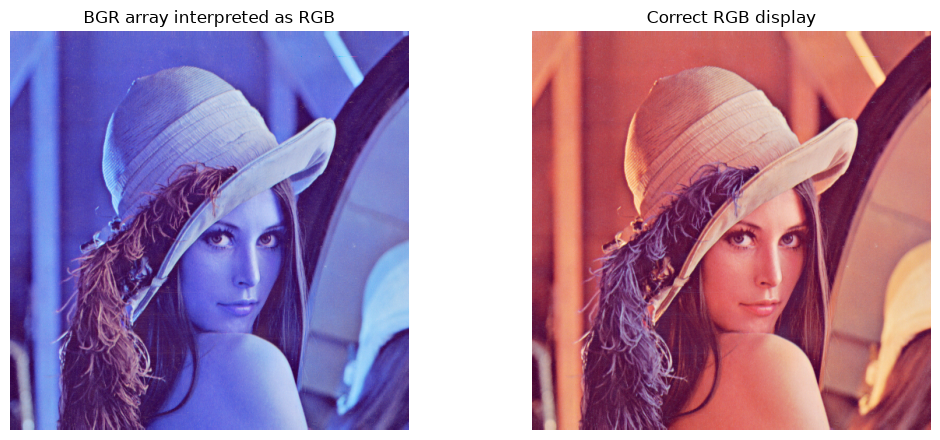

In [28]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(img_bgr)
axes[0].set_title("BGR array interpreted as RGB")
axes[1].imshow(img_rgb)
axes[1].set_title("Correct RGB display")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Conversion to HSV, CIELAB, and grayscale

OpenCV encodes 8-bit HSV as $H\in[0,179]$ and $S,V\in[0,255]$. Hue in degrees is approximately $2H$.

OpenCV encodes 8-bit CIELAB as $L_8,a_8,b_8\in[0,255]$. The corresponding conventional coordinates are

$$L^*=\frac{100}{255}L_8,\qquad a^*=a_8-128,\qquad b^*=b_8-128.$$

A converted HSV or CIELAB array must not be passed directly to `imshow`, because Matplotlib would interpret its three channels as RGB.

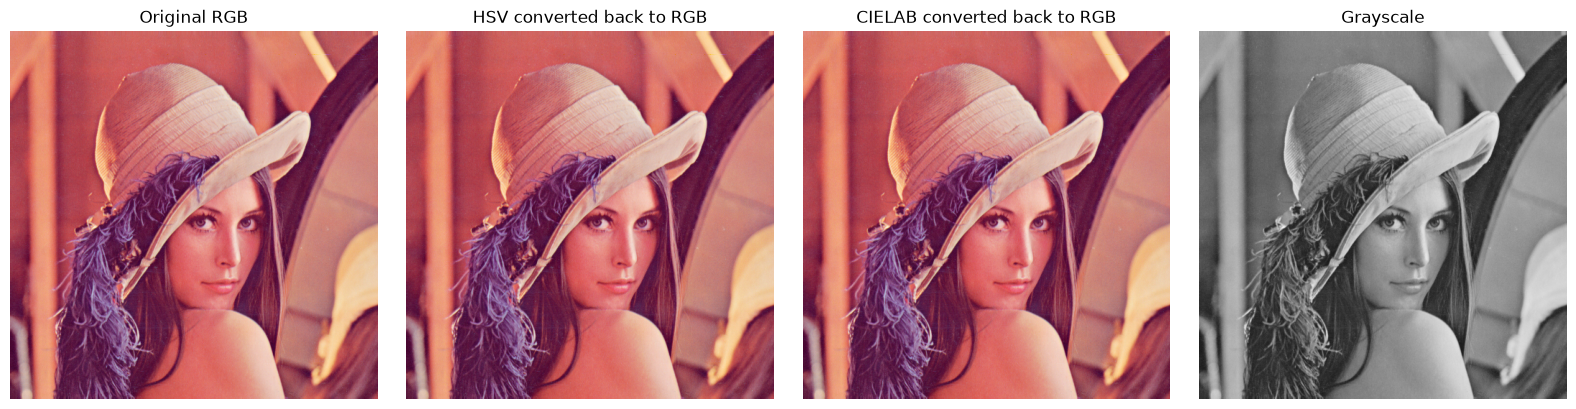

In [29]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Convert HSV and CIELAB back to RGB only for visual display.
hsv_display_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
lab_display_rgb = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
display_data = [
    (img_rgb, "Original RGB", None),
    (hsv_display_rgb, "HSV converted back to RGB", None),
    (lab_display_rgb, "CIELAB converted back to RGB", None),
    (img_gray, "Grayscale", "gray"),
]
for ax, (image, title, cmap) in zip(axes, display_data):
    ax.imshow(image, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Channel interpretation

RGB channels measure red, green, and blue contributions. HSV channels represent hue, saturation, and value. CIELAB channels represent perceptual lightness, the green–red axis, and the blue–yellow axis. Each channel is displayed as a scalar image, where brighter pixels indicate larger encoded values.

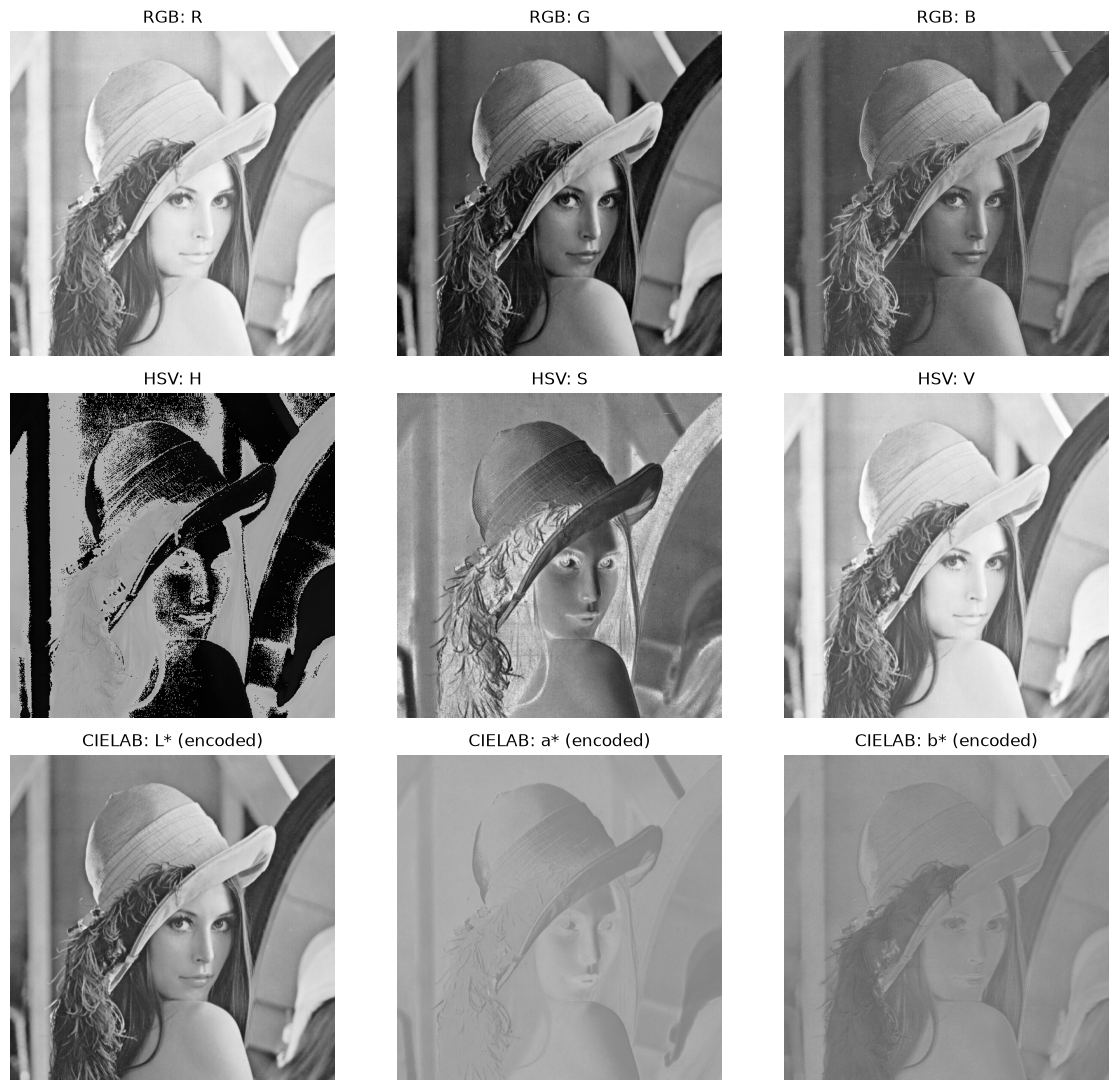

In [30]:
spaces = [
    (img_rgb, ["R", "G", "B"], "RGB"),
    (img_hsv, ["H", "S", "V"], "HSV"),
    (img_lab, ["L* (encoded)", "a* (encoded)", "b* (encoded)"], "CIELAB"),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for row, (image, channel_names, space_name) in enumerate(spaces):
    for col, channel_name in enumerate(channel_names):
        axes[row, col].imshow(image[:, :, col], cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_title(f"{space_name}: {channel_name}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 5. Coordinates of one pixel

The variables `x` and `y` denote the image column and row, respectively. Changing these values permits comparison of another pixel while preserving the same spatial location in every color space.

Pixel coordinates: x = 100, y = 100
BGR (OpenCV): [ 78  68 178]
RGB: [178  68  78]
HSV (OpenCV): [177 158 178]
HSV (degrees, %, %): (354.0, 62.0, 69.8)
CIELAB (OpenCV): [114 173 146]
CIELAB (L*, a*, b*): (44.71, 45.00, 18.00)
Grayscale: 102


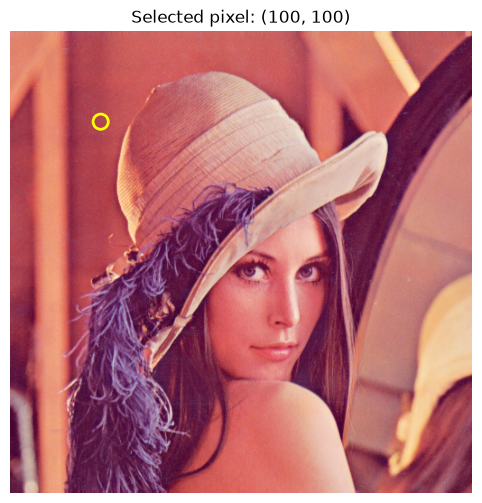

In [31]:
x, y = 100, 100
height, width = img_rgb.shape[:2]
if not (0 <= x < width and 0 <= y < height):
    raise IndexError(f"Pixel ({x}, {y}) is outside the image dimensions {width} x {height}.")

bgr = img_bgr[y, x]
rgb = img_rgb[y, x]
hsv = img_hsv[y, x]
lab_encoded = img_lab[y, x]
gray = img_gray[y, x]

h_deg = 2.0 * float(hsv[0])
s_percent = 100.0 * float(hsv[1]) / 255.0
v_percent = 100.0 * float(hsv[2]) / 255.0
lab_conventional = np.array([
    100.0 * float(lab_encoded[0]) / 255.0,
    float(lab_encoded[1]) - 128.0,
    float(lab_encoded[2]) - 128.0,
])

print(f"Pixel coordinates: x = {x}, y = {y}")
print(f"BGR (OpenCV): {bgr}")
print(f"RGB: {rgb}")
print(f"HSV (OpenCV): {hsv}")
print(f"HSV (degrees, %, %): ({h_deg:.1f}, {s_percent:.1f}, {v_percent:.1f})")
print(f"CIELAB (OpenCV): {lab_encoded}")
print(f"CIELAB (L*, a*, b*): ({lab_conventional[0]:.2f}, {lab_conventional[1]:.2f}, {lab_conventional[2]:.2f})")
print(f"Grayscale: {gray}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_rgb)
ax.scatter(x, y, s=120, facecolors="none", edgecolors="yellow", linewidths=2)
ax.set_title(f"Selected pixel: ({x}, {y})")
ax.axis("off")
plt.show()

## 6. Geometric interpretation of color spaces

A color is a point in a coordinate system. RGB occupies a cube, HSV uses hue as an angle, saturation as a radius, and value as a height, while CIELAB uses lightness and two opponent-color axes.

The point clouds below contain a spatially subsampled set of pixels from the image. Each point is displayed with its corresponding RGB color. The yellow star with a black border represents the pixel selected in the previous section.

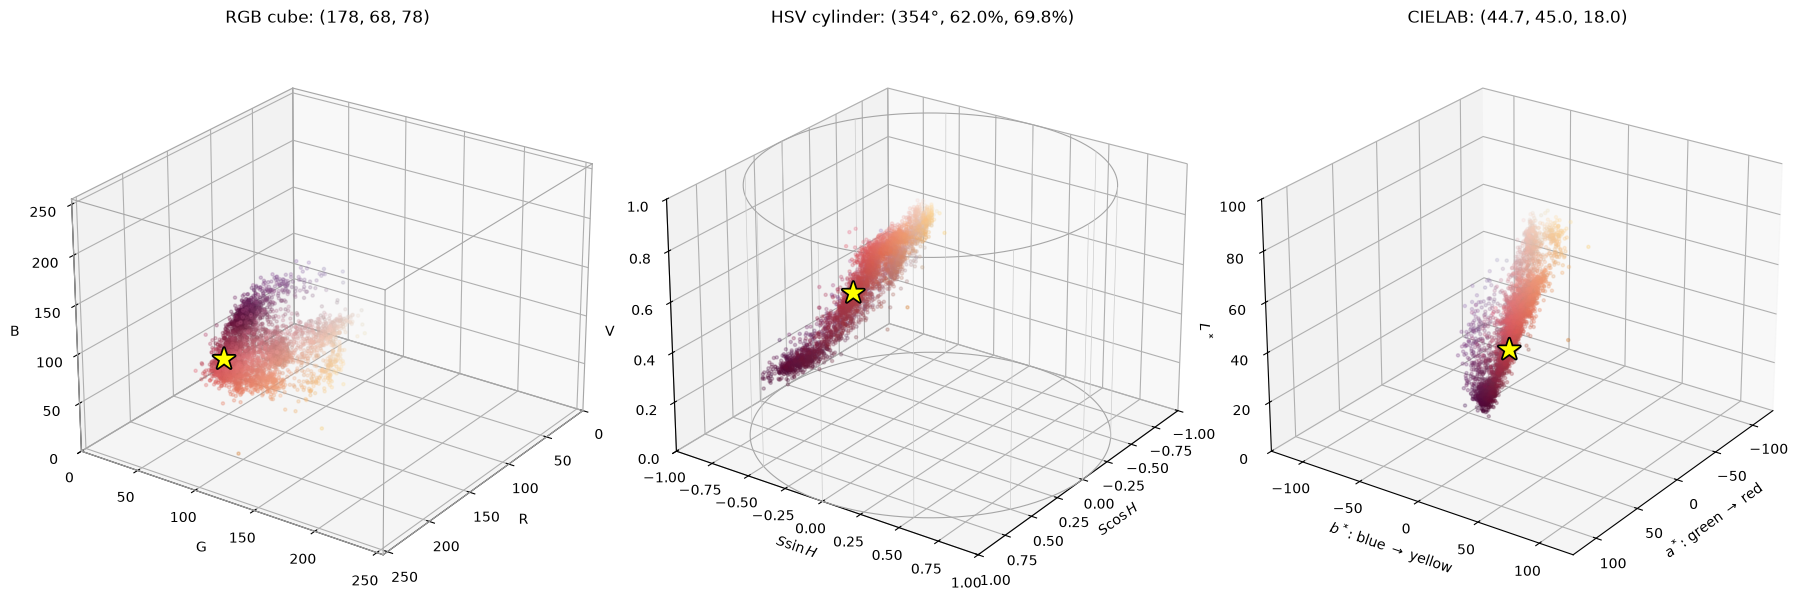

In [32]:
from matplotlib import patheffects
from mpl_toolkits.mplot3d import proj3d

# Subsample the image to preserve the color distribution without overcrowding the plots.
sampling_step = 8
rgb_samples = img_rgb[::sampling_step, ::sampling_step].reshape(-1, 3).astype(float)
hsv_samples = img_hsv[::sampling_step, ::sampling_step].reshape(-1, 3).astype(float)
lab_samples = img_lab[::sampling_step, ::sampling_step].reshape(-1, 3).astype(float)
point_colors = rgb_samples / 255.0

hue_radians = np.deg2rad(2.0 * hsv_samples[:, 0])
saturation = hsv_samples[:, 1] / 255.0
value = hsv_samples[:, 2] / 255.0
hsv_x = saturation * np.cos(hue_radians)
hsv_y = saturation * np.sin(hue_radians)

lab_l = 100.0 * lab_samples[:, 0] / 255.0
lab_a = lab_samples[:, 1] - 128.0
lab_b = lab_samples[:, 2] - 128.0

fig = plt.figure(figsize=(18, 6))

# Project the selected coordinate above the 3D point cloud so that it remains visible.
def mark_selected_point(ax, coordinates):
    projected_x, projected_y, _ = proj3d.proj_transform(*coordinates, ax.get_proj())
    marker = ax.annotate(
        "★",
        xy=(projected_x, projected_y),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="center",
        color="yellow",
        fontsize=20,
        fontweight="bold",
        zorder=100,
    )
    marker.set_path_effects([patheffects.withStroke(linewidth=2.5, foreground="black")])

# The RGB gamut is bounded by a cube with eight primary and secondary-color vertices.
ax_rgb = fig.add_subplot(1, 3, 1, projection="3d")
cube_corners = np.array([
    [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
    [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255],
])
cube_edges = [
    (i, j)
    for i in range(len(cube_corners))
    for j in range(i + 1, len(cube_corners))
    if np.count_nonzero(cube_corners[i] != cube_corners[j]) == 1
]
for i, j in cube_edges:
    ax_rgb.plot(*zip(cube_corners[i], cube_corners[j]), color="0.65", linewidth=0.8)
ax_rgb.scatter(
    rgb_samples[:, 0], rgb_samples[:, 1], rgb_samples[:, 2],
    c=point_colors, s=5, alpha=0.25, depthshade=False, rasterized=True,
)
ax_rgb.set(xlabel="R", ylabel="G", zlabel="B", xlim=(0, 255), ylim=(0, 255), zlim=(0, 255))
ax_rgb.set_title(f"RGB cube: ({rgb[0]}, {rgb[1]}, {rgb[2]})")
ax_rgb.view_init(elev=25, azim=35)
mark_selected_point(ax_rgb, tuple(rgb.astype(float)))

# In HSV, hue is angular, saturation is radial, and value is vertical.
ax_hsv = fig.add_subplot(1, 3, 2, projection="3d")
theta = np.linspace(0, 2 * np.pi, 361)
for level in (0.0, 1.0):
    ax_hsv.plot(np.cos(theta), np.sin(theta), level * np.ones_like(theta), color="0.65", linewidth=0.8)
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    ax_hsv.plot([np.cos(angle), np.cos(angle)], [np.sin(angle), np.sin(angle)], [0, 1], color="0.8", linewidth=0.5)
ax_hsv.scatter(hsv_x, hsv_y, value, c=point_colors, s=5, alpha=0.25, depthshade=False, rasterized=True)
selected_hue = np.deg2rad(h_deg)
selected_saturation = float(hsv[1]) / 255.0
selected_value = float(hsv[2]) / 255.0
selected_hsv_position = (
    selected_saturation * np.cos(selected_hue),
    selected_saturation * np.sin(selected_hue),
    selected_value,
)
ax_hsv.set(xlabel=r"$S\cos H$", ylabel=r"$S\sin H$", zlabel="V", xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1))
ax_hsv.set_title(f"HSV cylinder: ({h_deg:.0f}°, {s_percent:.1f}%, {v_percent:.1f}%)")
ax_hsv.view_init(elev=25, azim=35)
mark_selected_point(ax_hsv, selected_hsv_position)

# Conventional CIELAB coordinates expose lightness and opponent-color directions.
ax_lab = fig.add_subplot(1, 3, 3, projection="3d")
ax_lab.scatter(lab_a, lab_b, lab_l, c=point_colors, s=5, alpha=0.25, depthshade=False, rasterized=True)
ax_lab.set(xlabel=r"$a^*$: green $\rightarrow$ red", ylabel=r"$b^*$: blue $\rightarrow$ yellow", zlabel=r"$L^*$")
ax_lab.set(xlim=(-128, 127), ylim=(-128, 127), zlim=(0, 100))
ax_lab.set_title(
    f"CIELAB: ({lab_conventional[0]:.1f}, {lab_conventional[1]:.1f}, {lab_conventional[2]:.1f})"
)
ax_lab.view_init(elev=25, azim=35)
mark_selected_point(
    ax_lab,
    (lab_conventional[1], lab_conventional[2], lab_conventional[0]),
)

plt.tight_layout()
plt.show()

## 7. Numerical ranges in the current image

The theoretical encoding range and the observed range are different concepts. The following measurements describe only the pixels present in the loaded image.

In [33]:
space_channels = {
    "RGB": (img_rgb, ["R", "G", "B"]),
    "HSV": (img_hsv, ["H", "S", "V"]),
    "CIELAB": (img_lab, ["L", "a", "b"]),
}

print(f"{'Space':<10} {'Channel':<8} {'Minimum':>9} {'Maximum':>9} {'Mean':>10}")
print("-" * 50)
for space_name, (image, channel_names) in space_channels.items():
    for index, channel_name in enumerate(channel_names):
        channel = image[:, :, index]
        print(
            f"{space_name:<10} {channel_name:<8} "
            f"{channel.min():>9.0f} {channel.max():>9.0f} {channel.mean():>10.2f}"
        )

Space      Channel    Minimum   Maximum       Mean
--------------------------------------------------
RGB        R               54       255     180.22
RGB        G                3       248      99.05
RGB        B                8       225     105.41
HSV        H                0       179      92.26
HSV        S                5       246     133.30
HSV        V               59       255     180.43
CIELAB     L               27       248     131.56
CIELAB     a              123       189     161.30
CIELAB     b               90       210     139.39


## 8. Color segmentation in HSV

Hue is circular: red occurs near both ends of OpenCV's hue interval. Two hue ranges are therefore combined. Saturation and value thresholds reject nearly gray and very dark pixels. The thresholds describe an initial model and should be adjusted for the illumination and target object.

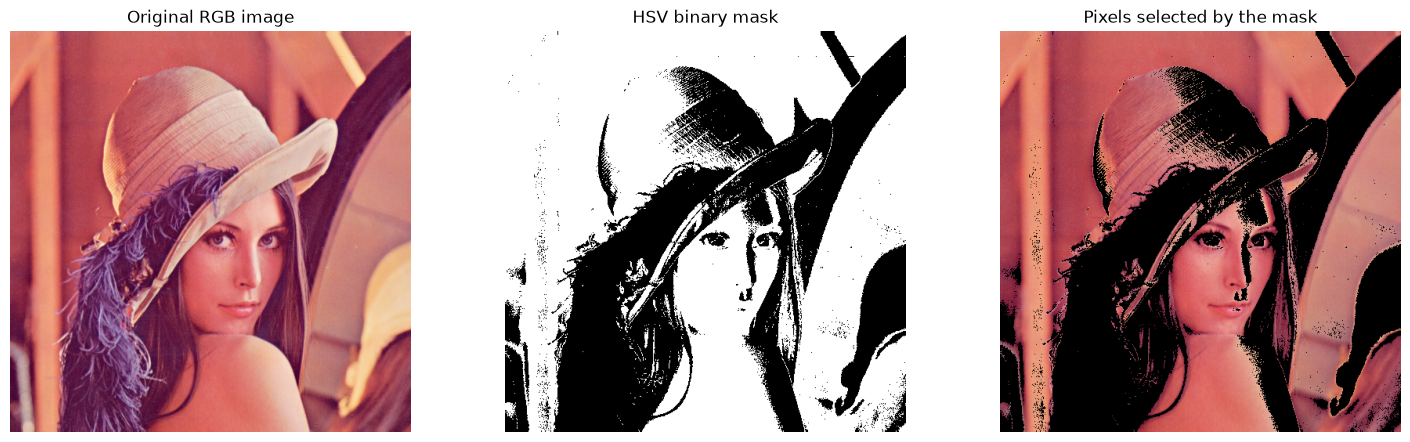

Selected pixels: 62.94% of the image


In [34]:
# Red occupies two intervals because hue is a circular coordinate.
lower_red_1 = np.array([0, 80, 50], dtype=np.uint8)
upper_red_1 = np.array([10, 255, 255], dtype=np.uint8)
lower_red_2 = np.array([170, 80, 50], dtype=np.uint8)
upper_red_2 = np.array([179, 255, 255], dtype=np.uint8)

mask_1 = cv2.inRange(img_hsv, lower_red_1, upper_red_1)
mask_2 = cv2.inRange(img_hsv, lower_red_2, upper_red_2)
red_mask = cv2.bitwise_or(mask_1, mask_2)
segmented_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=red_mask)
segmented_rgb = cv2.cvtColor(segmented_bgr, cv2.COLOR_BGR2RGB)
selected_fraction = np.count_nonzero(red_mask) / red_mask.size

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB image")
axes[1].imshow(red_mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("HSV binary mask")
axes[2].imshow(segmented_rgb)
axes[2].set_title("Pixels selected by the mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Selected pixels: {100 * selected_fraction:.2f}% of the image")

## Discussion questions

1. Why does an unconverted BGR image have incorrect colors in Matplotlib?
2. Which HSV channel changes most strongly when illumination changes?
3. Why are two hue intervals required to segment red?
4. Which CIELAB channel is most closely associated with illumination?
5. How do the HSV mask and selected-pixel percentage change when the saturation threshold is increased?
6. Where are grayscale colors located in each color space?
7. Why does HSV have a numerical discontinuity for red?
8. Which space, RGB or CIELAB, is better suited to describing perceptual color differences?